    # Practical 03 --- Choosing a Model Honestly

    **Overfitting, the train/test gap, and cross-validation**

    SCSE3040 Machine Learning Operations &middot; Bennett University &middot; Session 2026-27

    | | |
    |---|---|
    | **Lectures this follows** | L04-L05 |
    | **Course Outcome** | CO2 |
    | **Lab duration** | 120 minutes |
    | **Memory needed** | about 400 MB (fine on a 4 GB or 8 GB machine) |
    | **Extra software** | nothing beyond the course venv |
    | **Marks** | 10 |

    ---

    ## Aim

    1. Train three different models on the same data and compare them fairly.
2. See overfitting happen, and measure it as a gap between two scores.
3. Use cross-validation instead of trusting one lucky split.
4. Choose a model for a reason you can defend, not because it scored best.

    ---

    ## What you need to know first


In P02 you trained one model and it did well. A reasonable next thought is
"let me try a more powerful model and do even better". Today you find out why
that thought is dangerous.

A **decision tree** is a model that asks yes/no questions: *is the distance more
than 6 km? is it raining?* Ask enough questions and you can separate every
single training order from every other one. At that point the model has not
learned a pattern --- it has memorised the training data. It will look perfect
in training and fall apart on anything new.

That failure has a name: **overfitting**. And it has a measurement. Score the
model twice, once on the data it trained on and once on data it has never seen.
The distance between those two numbers is the **train/test gap**. A small gap
means the model learned something general. A big gap means it memorised.

There is one more problem to fix. In P02 your test set was one particular 120
orders, chosen by one particular seed. What if those 120 happened to be easy?
**Cross-validation** removes that luck: it cuts the data into 5 equal parts,
trains 5 times, and each time tests on a different part. You get 5 scores
instead of 1, and you report the average. It costs 5 times the computing time,
which on this dataset means well under a second.

The habit to build today: *the best score is not the best model.* A simple model
that scores almost as well is usually the one to ship, because you can explain
it, it trains faster, and it breaks less.

    ---

    ## Before you start

    - Practical P02 is finished. You can split data, train a model and read an MAE.
- You remember that the test set is the only honest score.

    ### How to run a cell

    Click on a grey code cell, then press **Shift + Enter**. The cell runs and
    the cursor moves to the next one. A number appears in the `[ ]` on the left
    when the cell has finished.

    **Run the cells in order, from the top.** A later cell almost always uses
    something an earlier cell created. If you jump ahead you will see a
    `NameError`, which just means "you have not made that thing yet".

    If everything goes wrong, use the menu: **Kernel -> Restart Kernel and Clear
    All Outputs**, then start again from the first cell. Nothing is damaged by
    doing this.

In [51]:
# Step 0 --- check the workbench before we start.
# This cell only looks; it changes nothing. Run it and read the last line.

import sys
from pathlib import Path

print("Python  :", sys.version.split()[0])
print("Folder  :", Path.cwd().name)

_missing = []
for _name in ['numpy', 'pandas', 'sklearn', 'matplotlib']:
    try:
        __import__(_name)
    except ImportError:
        _missing.append(_name)

for _name in ['numpy', 'pandas', 'sklearn', 'matplotlib']:
    _mark = "missing" if _name in _missing else "ok"
    print(f"  {_name:<14} {_mark}")

if _missing:
    print()
    print("STOP. Some libraries are missing:", ", ".join(_missing))
    print("Ask your instructor to run the setup in labs/SETUP.md.")
else:
    print()
    print("All good. You can carry on to Step 1.")

Python  : 3.12.10
Folder  : P03-model-choice
  numpy          ok
  pandas         ok
  sklearn        ok
  matplotlib     ok

All good. You can carry on to Step 1.


---

## Step 0b --- the dataset

Every practical in this course uses the same 600 food deliveries.
The next cell makes sure the file is there.

In [52]:
# The delivery-time dataset every practical in this course uses.
# If the file is missing we build it again from the same seed, so every
# student in the room gets byte-for-byte the same 600 rows.

import csv
from pathlib import Path

import numpy as np

SEED = 42
N_ROWS = 600
DATA = Path("..") / "data" / "delivery_times.csv"


def make_delivery_csv(path=DATA):
    """Write the 600-row delivery dataset. Same formula as the lectures."""
    rng = np.random.default_rng(SEED)
    distance_km = np.round(rng.uniform(0.5, 12.0, N_ROWS), 2)
    prep_time_min = np.round(rng.uniform(5, 30, N_ROWS), 0)
    traffic_level = rng.integers(1, 4, N_ROWS)
    rain = rng.binomial(1, 0.25, N_ROWS)
    delivery_min = np.round(
        6.0
        + 3.1 * distance_km
        + 0.65 * prep_time_min
        + 4.2 * traffic_level
        + 5.5 * rain
        + rng.normal(0, 2.5, N_ROWS),
        1,
    )
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(["distance_km", "prep_time_min", "traffic_level",
                    "rain", "delivery_min"])
        for i in range(N_ROWS):
            w.writerow([distance_km[i], int(prep_time_min[i]),
                        int(traffic_level[i]), int(rain[i]), delivery_min[i]])
    return path


if not DATA.exists():
    make_delivery_csv()
    print("dataset rebuilt ->", DATA)
else:
    print("dataset found   ->", DATA)

dataset found   -> ..\data\delivery_times.csv


---

# Walkthrough

Read each step, then run its cell.

### Step 1 --- Set up the data once, for all three models

Same data, same split, same seed as P02. Every model today gets
exactly the same deal --- otherwise the comparison is worthless.

In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

orders = pd.read_csv(DATA)

FEATURES = ["distance_km", "prep_time_min", "traffic_level", "rain"]
X = orders[FEATURES]
y = orders["delivery_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("train:", len(X_train), " test:", len(X_test))

train: 480  test: 120


### Step 2 --- A helper that scores a model both ways

We will do the same two measurements many times today, so write
them once. This function returns the training MAE, the test MAE,
and the gap between them.

In [54]:
from sklearn.metrics import mean_absolute_error

def score_both_ways(model, name):
    """Train the model, then score it on train and on test."""
    model.fit(X_train, y_train)
    train_mae = mean_absolute_error(y_train, model.predict(X_train))
    test_mae = mean_absolute_error(y_test, model.predict(X_test))
    gap = test_mae - train_mae
    print(f"{name:<26} train {train_mae:5.2f}   "
          f"test {test_mae:5.2f}   gap {gap:5.2f}")
    return {"name": name, "train": train_mae,
            "test": test_mae, "gap": gap}

print("helper ready")

helper ready


### Step 3 --- Model 1: linear regression, the honest baseline

The model from P02. Watch the gap: it should be tiny, because a
straight line is too simple to memorise anything.

In [55]:
from sklearn.linear_model import LinearRegression

linear = score_both_ways(LinearRegression(), "LinearRegression")

LinearRegression           train  2.04   test  1.92   gap -0.11


Train and test scores almost equal. This model is not overfitting.
It may not be the most accurate thing possible, but it is telling
you the truth.

### Step 4 --- Model 2: a decision tree with no limits

Now the dangerous one. A decision tree with no maximum depth is
allowed to keep asking questions until every training order sits in
its own little box.

Look at the training score first. Then look at the test score.

In [56]:
from sklearn.tree import DecisionTreeRegressor

wild_tree = score_both_ways(
    DecisionTreeRegressor(random_state=42), "DecisionTree (no limit)"
)

DecisionTree (no limit)    train  0.00   test  3.43   gap  3.43


A training MAE near **zero** and a much worse test MAE. The model
got every training order perfectly right and learned nothing useful.

**That gap is overfitting.** You have now seen it happen, not just
been told about it.

### Step 5 --- Model 3: the same tree, but shallow

Now stop the tree early. `max_depth=4` means it may only ask four
questions before it has to answer. It can no longer memorise.

In [57]:
small_tree = score_both_ways(
    DecisionTreeRegressor(max_depth=4, random_state=42),
    "DecisionTree (depth 4)",
)

DecisionTree (depth 4)     train  3.66   test  4.23   gap  0.57


Worse on training, better on test, and a far smaller gap. Limiting
a model's freedom made it *more* useful. That idea is the whole of
model selection.

### Step 6 --- Model 4: a random forest

A **random forest** grows many different trees and averages their
answers. Individual trees still overfit, but their mistakes point in
different directions and largely cancel out.

We use 50 trees. More would be slower and no better here.

In [58]:
from sklearn.ensemble import RandomForestRegressor

forest = score_both_ways(
    RandomForestRegressor(n_estimators=50, random_state=42),
    "RandomForest (50 trees)",
)

RandomForest (50 trees)    train  1.00   test  2.39   gap  1.39


### Step 7 --- Put the four results side by side

Never compare models from memory. Put them in a table.

In [59]:
results = pd.DataFrame([linear, wild_tree, small_tree, forest])
results = results.round(2).sort_values("test")

print(results.to_string(index=False))
print()
best = results.iloc[0]
print(f"Lowest test MAE: {best['name']} at {best['test']:.2f} minutes")

                   name  train  test   gap
       LinearRegression   2.04  1.92 -0.11
RandomForest (50 trees)   1.00  2.39  1.39
DecisionTree (no limit)   0.00  3.43  3.43
 DecisionTree (depth 4)   3.66  4.23  0.57

Lowest test MAE: LinearRegression at 1.92 minutes


Read the `gap` column as carefully as the `test` column. A model
with a good test score and a huge gap got lucky, and luck does not
survive contact with real users.

### Step 8 --- Draw the gap, because a table makes you read

The table is correct but slow --- you must read eight numbers and
subtract in your head. A chart does the subtraction for your eyes.

**matplotlib** is Python's standard charting library. It has been
sitting in your course environment since P01; today it earns its
place. The first line, `%matplotlib inline`, tells Jupyter to draw
the picture right below the cell.

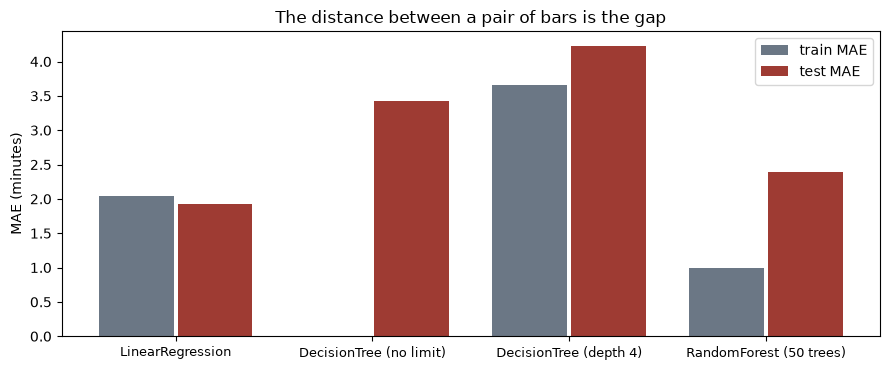

In [60]:
%matplotlib inline
import matplotlib.pyplot as plt

four = [linear, wild_tree, small_tree, forest]
xs = np.arange(len(four))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(xs - 0.2, [m["train"] for m in four], 0.38,
       label="train MAE", color="#6B7785")
ax.bar(xs + 0.2, [m["test"] for m in four], 0.38,
       label="test MAE", color="#9E3B33")
ax.set_xticks(xs, [m["name"] for m in four], fontsize=9)
ax.set_ylabel("MAE (minutes)")
ax.set_title("The distance between a pair of bars is the gap")
ax.legend()
plt.tight_layout()
plt.show()

Look at the pair for the no-limit tree. Its grey train bar has
**vanished** --- an MAE of 0.00 draws as no bar at all --- while its
red test bar is among the tallest. Bars far apart mean the model
memorised; bars close together mean it learned.

The linear model's two bars are the closest pair on the chart.
That is what honesty looks like.

### Step 9 --- Stop trusting one split: cross-validation

Every number above came from one 120-order test set. Change the
seed and they all move a little.

**5-fold cross-validation** cuts the data into 5 parts and trains 5
times, testing on a different part each time. We report the average
and the spread.

scikit-learn reports errors as *negative* numbers, because its
convention is that bigger is better. We flip the sign back.

In [61]:
from sklearn.model_selection import cross_val_score

def cross_validate(model, name):
    """Average MAE over 5 different train/test splits."""
    scores = -cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_absolute_error"
    )
    print(f"{name:<26} MAE {scores.mean():5.2f} "
          f"(+/- {scores.std():4.2f})")
    return scores.mean()

cv_linear = cross_validate(LinearRegression(), "LinearRegression")
cv_tree = cross_validate(
    DecisionTreeRegressor(max_depth=4, random_state=42),
    "DecisionTree (depth 4)")
cv_forest = cross_validate(
    RandomForestRegressor(n_estimators=50, random_state=42),
    "RandomForest (50 trees)")

LinearRegression           MAE  2.03 (+/- 0.16)
DecisionTree (depth 4)     MAE  4.57 (+/- 0.18)
RandomForest (50 trees)    MAE  2.69 (+/- 0.40)


The `+/-` is the spread across the 5 folds. If two models are closer
together than their spread, you cannot honestly say one is better.

### Step 10 --- Tune one setting, properly

How deep should the tree be? Do not guess, and do not try depths on
the test set --- that would leak the answers.

Try each depth with cross-validation, which never touches the test
set at all.

In [62]:
depths = [2, 3, 4, 6, 8, None]
scores_by_depth = {}

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    mae = -cross_val_score(
        tree, X, y, cv=5, scoring="neg_mean_absolute_error"
    ).mean()
    scores_by_depth[depth] = round(mae, 3)
    print(f"max_depth={str(depth):<5} MAE {mae:5.2f}")

best_depth = min(scores_by_depth, key=scores_by_depth.get)
print()
print("best depth:", best_depth)

max_depth=2     MAE  5.86
max_depth=3     MAE  4.85
max_depth=4     MAE  4.57
max_depth=6     MAE  3.64
max_depth=8     MAE  3.39
max_depth=None  MAE  3.48

best depth: 8


Read the **shape**, not just the winner.

Depth 2 is the worst of all: too simple to capture anything, which
is called **underfitting**. The scores improve as the tree is
allowed more room, reach their best in the middle, and then get
slightly worse again when the limit is removed altogether.

Too rigid and too free are both bad. The good answer is in between,
and the only way to find it is to measure --- which is what you just
did, without ever touching the test set.

### Step 11 --- Draw the sweep, because ten numbers hide a shape

The loop printed six scores. Their *shape* is the real lesson, and
a shape is easier to see than to read. Draw MAE against depth.

The red circle marks the depth cross-validation liked best.

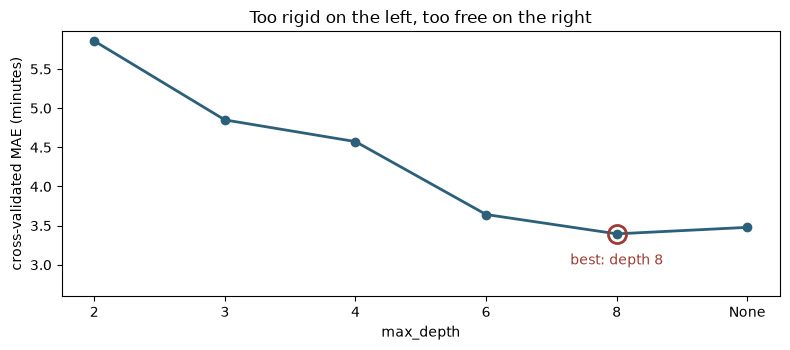

In [63]:
xs = np.arange(len(depths))
maes = [scores_by_depth[d] for d in depths]
best_i = int(np.argmin(maes))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(xs, maes, marker="o", color="#2C5F79", linewidth=2)
ax.plot(xs[best_i], maes[best_i], marker="o", markersize=13,
        markerfacecolor="none", markeredgecolor="#9E3B33",
        markeredgewidth=2)
ax.annotate(f"best: depth {depths[best_i]}",
            (xs[best_i], maes[best_i]),
            xytext=(0, -22), textcoords="offset points",
            ha="center", color="#9E3B33")
ax.set_xticks(xs, [str(d) for d in depths])
ax.set_ylim(bottom=min(maes) - 0.8)
ax.set_xlabel("max_depth")
ax.set_ylabel("cross-validated MAE (minutes)")
ax.set_title("Too rigid on the left, too free on the right")
plt.tight_layout()
plt.show()

Now the shape is unmissable. The left end towers over everything:
depth 2 is the worst score on the whole chart --- **underfitting**,
a model too rigid to learn anything. The curve falls as the tree
earns more freedom, bottoms out in the middle, then ticks back up
when the last limit is removed.

Both ends of the curve are bad. The answer lives at the bottom,
and you found it without ever touching the test set.

### Step 12 --- Choose, and be able to say why

Now make the decision the way a professional would, out loud.

In [64]:
print("Cross-validated MAE, best first:")
for name, mae in sorted(
    {"LinearRegression": cv_linear,
     "DecisionTree(4)": cv_tree,
     "RandomForest(50)": cv_forest}.items(),
    key=lambda kv: kv[1],
):
    print(f"  {name:<20} {mae:5.2f}")

print()
print("Our choice for the delivery service: LinearRegression.")
print("Reasons:")
print("  1. It has the lowest cross-validated error here.")
print("  2. It trains in milliseconds and needs almost no memory.")
print("  3. We can read its coefficients and explain a prediction")
print("     to a restaurant owner. Nobody can read 50 trees.")
print()
print("Be careful with reason 1. This dataset really was built")
print("from a straight line, so a straight line wins. On messier")
print("real data the forest usually wins instead -- and then you")
print("must decide what its extra accuracy is worth, against")
print("reasons 2 and 3, which do not change.")

Cross-validated MAE, best first:
  LinearRegression      2.03
  RandomForest(50)      2.69
  DecisionTree(4)       4.57

Our choice for the delivery service: LinearRegression.
Reasons:
  1. It has the lowest cross-validated error here.
  2. It trains in milliseconds and needs almost no memory.
  3. We can read its coefficients and explain a prediction
     to a restaurant owner. Nobody can read 50 trees.

Be careful with reason 1. This dataset really was built
from a straight line, so a straight line wins. On messier
real data the forest usually wins instead -- and then you
must decide what its extra accuracy is worth, against
reasons 2 and 3, which do not change.


You will not always choose the simple model. But you must always be
able to say why you chose what you chose. "It scored best" is not a
reason a senior engineer will accept on its own --- and, as the last
paragraph says, it will not always be true either.

---

# Your turn

The walkthrough above is finished. Now you write some code.

There are **3 tasks**. Each one is small. Each one has a hint.
Do them in order.

Where you see `# TODO`, replace that line with your own code. Do not delete
the variable name on the left of the `=` sign --- the self-check at the
bottom looks for exactly that name.

When you have tried all three, run the **self-check** cell at the end. It
prints a table telling you which tasks are correct. You can run it as many
times as you like.

### Task T1 --- Measure overfitting yourself


    Train a `DecisionTreeRegressor` with `max_depth=12` and
    `random_state=42`, and work out its train/test gap by hand.

    Store the three numbers in `T1_train_mae`, `T1_test_mae` and `T1_gap`.

    `T1_gap` must be the test MAE **minus** the train MAE.


> **Hint.** You may not use `score_both_ways` for this one -- write the three lines out, so you can see what the helper was doing. Fit the tree, then call `mean_absolute_error` twice: once with `y_train` and `X_train`, once with `y_test` and `X_test`.

In [65]:
deep_tree = DecisionTreeRegressor(max_depth=12, random_state=42)

# TODO: fit it on the training data
# TODO: measure the MAE on the training data


# Fit the tree on the training data
deep_tree.fit(X_train, y_train)

# Measure MAE on the training data
T1_train_mae = mean_absolute_error(y_train, deep_tree.predict(X_train))

# Measure MAE on the test data
T1_test_mae = mean_absolute_error(y_test, deep_tree.predict(X_test))

# Test MAE minus train MAE
T1_gap = T1_test_mae - T1_train_mae

print(f"train {T1_train_mae}  test {T1_test_mae}  gap {T1_gap}")
T1_train_mae = None
# TODO: measure the MAE on the test data
T1_test_mae = None
# TODO: the gap between them
T1_gap = None

print(f"train {T1_train_mae}  test {T1_test_mae}  gap {T1_gap}")

train 0.04695601851851851  test 3.397986111111111  gap 3.3510300925925924
train None  test None  gap None


### Task T2 --- Tune the forest, without touching the test set


    A random forest has a setting `max_depth` too. Use **5-fold
    cross-validation** to find which of `[2, 4, 6, None]` is best for a
    `RandomForestRegressor(n_estimators=50, random_state=42)`.

    Build a dictionary `T2_scores` mapping each depth to its
    cross-validated MAE, then put the winning depth in `T2_best_depth`.

    You must not use `X_test` or `y_test` anywhere in this task.


> **Hint.** Step 10 does exactly this for a single tree. Copy that loop and change two things: the model, and the list of depths. The winner is `min(T2_scores, key=T2_scores.get)`.

In [66]:
T2_depths = [2, 4, 6, None]

# Cross-validate a 50-tree forest at each depth
T2_scores = {}

for depth in T2_depths:
    forest = RandomForestRegressor(
        n_estimators=50,
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        forest,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    T2_scores[depth] = -scores.mean()

# Which depth had the lowest MAE?
T2_best_depth = min(T2_scores, key=T2_scores.get)

print(T2_scores)
print("best:", T2_best_depth)

{2: np.float64(5.422545124201891), 4: np.float64(3.5515271170143676), 6: np.float64(2.830879533681162), None: np.float64(2.7500833333333317)}
best: None


### Task T3 --- A comparison you can reuse


    Write a function `compare(models)` that takes a **dictionary** of
    `{name: model}` and returns a dictionary of `{name: test MAE}`.

    It must fit each model on `X_train`/`y_train` and score it on
    `X_test`/`y_test`.

    Then call it on the three models given in the stub and store the answer
    in `T3_table`.


> **Hint.** Loop over `models.items()`, call `.fit(...)`, then `mean_absolute_error(y_test, m.predict(X_test))`, and collect the results into a new dictionary that you `return` at the end.

In [67]:
def compare(models):
    # Fit each model and calculate its test MAE
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        results[name] = mean_absolute_error(y_test, predictions)

    return results


T3_table = compare({
    "linear": LinearRegression(),
    "tree4": DecisionTreeRegressor(max_depth=4, random_state=42),
    "forest": RandomForestRegressor(n_estimators=50, random_state=42),
})

print(T3_table)

{'linear': 1.924653079833835, 'tree4': 4.228332168713071, 'forest': 2.391816666666663}


---

## Self-check

Run the cell below to mark your work.

In [69]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

deep_tree = DecisionTreeRegressor(max_depth=12, random_state=42)
deep_tree.fit(X_train, y_train)

T1_train_mae = mean_absolute_error(y_train, deep_tree.predict(X_train))
T1_test_mae = mean_absolute_error(y_test, deep_tree.predict(X_test))
T1_gap = T1_test_mae - T1_train_mae

print(T1_train_mae)
print(T1_test_mae)
print(T1_gap)

0.04695601851851851
3.397986111111111
3.3510300925925924


In [70]:
print("Stored train:", T1_train_mae)
print("Actual train:", mean_absolute_error(y_train, deep_tree.predict(X_train)))

print("Stored test:", T1_test_mae)
print("Actual test:", mean_absolute_error(y_test, deep_tree.predict(X_test)))

print("Stored gap:", T1_gap)
print("Expected gap:", T1_test_mae - T1_train_mae)

Stored train: 0.04695601851851851
Actual train: 0.04695601851851851
Stored test: 3.397986111111111
Actual test: 3.397986111111111
Stored gap: 3.3510300925925924
Expected gap: 3.3510300925925924


In [71]:
# ------------------------------------------------------------------
# SELF-CHECK --- run this when you have attempted the tasks above.
# It never breaks your notebook. A task you have not done yet simply
# shows FAIL.
# ------------------------------------------------------------------

_results = []


def _check(label, fn):
    """Evaluate one graded condition without ever raising."""
    try:
        ok = bool(fn())
    except Exception:
        ok = False
    _results.append((label, ok))


_check('T1 | the depth-12 tree is trained', lambda: hasattr(deep_tree, 'tree_'))
_check("T1 | T1_train_mae and T1_test_mae are that tree's two scores", lambda: abs(float(T1_train_mae) - mean_absolute_error(y_train, deep_tree.predict(X_train))) < 0.01 and abs(float(T1_test_mae) - mean_absolute_error(y_test, deep_tree.predict(X_test))) < 0.01)
_check('T1 | T1_gap is test minus train, and it is positive', lambda: abs(float(T1_gap) - (float(T1_test_mae) - float(T1_train_mae))) < 1e-6 and float(T1_gap) > 0)
_check('T2 | T2_scores has one score per depth', lambda: set(T2_scores) == {2, 4, 6, None})
_check('T2 | every score is a plausible MAE in minutes', lambda: all(0 < float(v) < 20 for v in T2_scores.values()))
_check('T2 | T2_best_depth is the depth with the lowest score', lambda: T2_best_depth == min(T2_scores, key=T2_scores.get))
_check('T3 | compare() returns one score per model', lambda: set(T3_table) == {'linear', 'tree4', 'forest'})
_check('T3 | the linear score matches the walkthrough', lambda: abs(float(T3_table['linear']) - linear['test']) < 0.01)

print("==================================================================")
print("SELF-CHECK   Practical 03 --- Choosing a Model Honestly")
print("==================================================================")
for _label, _ok in _results:
    print(f"  [{'PASS' if _ok else 'FAIL'}]  {_label}")
print("------------------------------------------------------------------")
_passed = sum(1 for _, _ok in _results if _ok)
print(f"  {_passed} of {len(_results)} checks passed")
print("==================================================================")
if _passed == len(_results):
    print("Well done. Save the notebook and submit it.")
else:
    print("Read the FAIL lines above, fix those tasks, run this cell again.")

SELF-CHECK   Practical 03 --- Choosing a Model Honestly
  [PASS]  T1 | the depth-12 tree is trained
  [PASS]  T1 | T1_train_mae and T1_test_mae are that tree's two scores
  [PASS]  T1 | T1_gap is test minus train, and it is positive
  [PASS]  T2 | T2_scores has one score per depth
  [PASS]  T2 | every score is a plausible MAE in minutes
  [PASS]  T2 | T2_best_depth is the depth with the lowest score
  [PASS]  T3 | compare() returns one score per model
  [PASS]  T3 | the linear score matches the walkthrough
------------------------------------------------------------------
  8 of 8 checks passed
Well done. Save the notebook and submit it.


    ---

    ## What to submit

    1. This notebook, with every cell run and its output visible.
2. In a markdown cell at the end, three sentences: which model you would put in front of real customers, why, and what you gave up by choosing it.

    Name your file `PXX_<your-roll-number>.ipynb` before you upload it.

    ### How this practical is marked

    | What is marked | Marks |
    |---|---|
    | Walkthrough run end to end, outputs visible | 3 |
| Task T1 --- overfitting measured as a gap | 2 |
| Task T2 --- best setting found by cross-validation | 3 |
| Task T3 --- a reusable comparison function | 2 |
    | **Total** | **10** |

    ---

    ## Read more

    - scikit-learn --- Underfitting vs overfitting --- <https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html>
- scikit-learn --- Cross-validation --- <https://scikit-learn.org/stable/modules/cross_validation.html>
- scikit-learn --- Decision trees --- <https://scikit-learn.org/stable/modules/tree.html>
- scikit-learn --- Ensemble methods --- <https://scikit-learn.org/stable/modules/ensemble.html>
- matplotlib --- Quick start guide --- <https://matplotlib.org/stable/users/explain/quick_start.html>